# Introducción a MLOps (Notebook 01)

En este notebook vas a recorrer un flujo completo (y reproducible) de *machine learning* para **clasificación binaria** usando *scikit-learn*:

- Generación de datos sintéticos (con valores faltantes para simular “datos reales”).
- EDA mínimo para entender tipos de variables y calidad del dataset.
- Feature engineering sencillo.
- Split de train/test.
- **Pipeline** de preprocesamiento + modelo (evita *data leakage*).
- Evaluación con métricas: *accuracy*, *precision*, *recall*, *F1*, ROC-AUC, matriz de confusión y efectos del **umbral** (*threshold*).

Objetivo: no “ganar” el mejor score (los datos son sintéticos), sino practicar buenas prácticas y entender qué significa la salida del modelo.
__________________________________

## ¿Qué es *data leakage*? (explicación fácil)

**Data leakage** (fuga de información) pasa cuando el modelo “hace trampa” sin querer, porque en entrenamiento ve información que **no debería ver**.

Piensa en esto:

- En `train` el modelo *aprende*.
- En `test` el modelo debe comportarse como si fueran **datos nuevos**.

Hay *leakage* si (por accidente) usas datos del `test` para preparar el `train`.

### Ejemplo muy común
Si calculas la **mediana** para imputar valores faltantes usando *todo el dataset* (train + test), entonces el modelo está usando información del test.

### ¿Por qué el `Pipeline` ayuda?
Porque el flujo correcto es:

1. Separar `train/test`
2. Hacer `pipeline.fit(X_train, y_train)` → aquí el pipeline aprende (medianas, escalado, one-hot) **solo con train**
3. Hacer `pipeline.predict(X_test)` → aquí solo aplica las mismas reglas al test

Resultado: la evaluación es más realista (más parecida a producción).

Ejemplo:
Supongamos un dataset con una feature a la cual le hacen falta valores en algunos registros.

- Calculas la mediana solo con X_train.
- Rellenas X_train con esa mediana.
- Rellenas X_test con esa misma mediana (la del train).

In [33]:
%load_ext autoreload
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import UserGenerator

In [35]:
generator_data = UserGenerator(seed=42, n_samples=10000)
df = generator_data.create_dataset()

df.head()

Generando datos sintéticos de usuarios para targeting de promociones...
✅ Agregados 493 valores nulos en 'age_group' (5.0%)
✅ Agregados 298 valores nulos en 'location' (3.0%)
✅ Agregados 181 valores nulos en 'device_type' (2.0%)
✅ Agregados 106 valores nulos en 'subscription_type' (1.0%)
✅ Agregados 777 valores nulos en 'avg_order_value' (8.0%)
✅ Agregados 1474 valores nulos en 'last_purchase_days' (15.0%)
✅ Agregados 999 valores nulos en 'time_on_site_minutes' (10.0%)
✅ Agregados 954 valores nulos en 'pages_per_session' (10.0%)
✅ Agregados 1221 valores nulos en 'cart_abandonment_rate' (12.0%)
✅ Agregados 800 valores nulos en 'purchase_frequency' (8.0%)


,user_id,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,USER-000001,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1
1,USER-000002,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0
2,USER-000003,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1
3,USER-000004,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0
4,USER-000005,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1


In [36]:
days = df['days_since_registration'].clip(lower=1)  # Evitar división por cero, dejar 1 si el valor es menor a 0

df['total_purchases_per_day'] = df['total_purchases'] / days

df["days_between_first_and_last_purchase"] = df["days_since_registration"] - df["last_purchase_days"]

df["bucket_avg_order_value"] = pd.cut(df["avg_order_value"], bins=3, labels=["low", "medium", "high"])

## 1) EDA rápido: entender los datos

En esta sección buscamos:

- Tipos de variables:
  - **Categóricas** (texto / `object`): requieren codificación (por ejemplo One-Hot).
  - **Numéricas** (`int`, `float`): suelen requerir imputación y, para algunos modelos, escalado.
- Calidad del dataset:
  - Porcentaje de valores faltantes (`NaN`).
  - Rangos de valores y posibles outliers.

Nota MLOps: la imputación/transformaciones se deben hacer **dentro del pipeline** para evitar *data leakage* (contaminar el entrenamiento con información del test).

<Axes: >

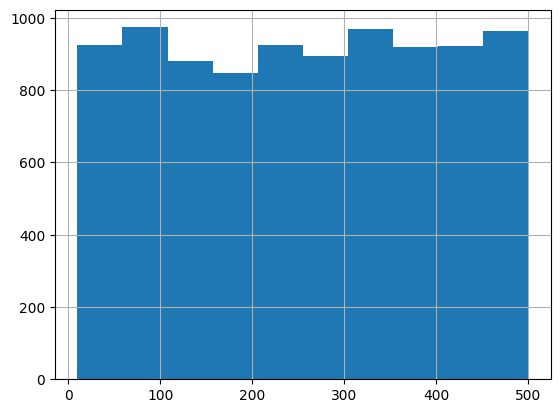

In [37]:
df.avg_order_value.hist()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   user_id                               10000 non-null  object  
 1   age_group                             9507 non-null   object  
 2   location                              9702 non-null   object  
 3   device_type                           9819 non-null   object  
 4   subscription_type                     9894 non-null   object  
 5   days_since_registration               10000 non-null  int64   
 6   total_purchases                       10000 non-null  int64   
 7   avg_order_value                       9223 non-null   float64 
 8   last_purchase_days                    8526 non-null   float64 
 9   sessions_last_30_days                 10000 non-null  int64   
 10  time_on_site_minutes                  9001 non-null   float64 
 11  pag

### Análisis de nulos

In [39]:
# Cálculo de nulos y su porcentaje
missing_data = df.isnull().sum().to_frame(name='Total de nulos')
missing_data['Porcentaje (%)'] = (missing_data['Total de nulos'] / len(df)) * 100
print(missing_data.sort_values(by='Porcentaje (%)', ascending=False))

                                      Total de nulos  Porcentaje (%)
days_between_first_and_last_purchase            1474           14.74
last_purchase_days                              1474           14.74
cart_abandonment_rate                           1221           12.21
time_on_site_minutes                             999            9.99
pages_per_session                                954            9.54
purchase_frequency                               800            8.00
bucket_avg_order_value                           777            7.77
avg_order_value                                  777            7.77
age_group                                        493            4.93
location                                         298            2.98
device_type                                      181            1.81
subscription_type                                106            1.06
user_id                                            0            0.00
days_since_registration           

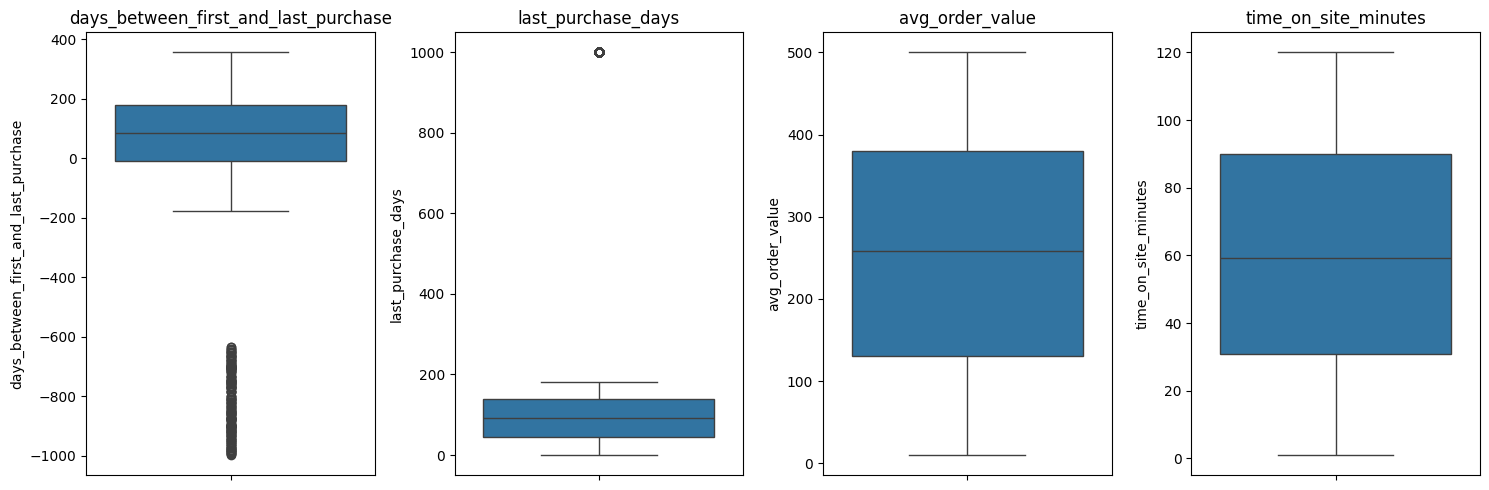

In [40]:
# Se seleccionan las variables con más nulos para ver su distribución
cols_to_check = [
    'days_between_first_and_last_purchase', 
    'last_purchase_days', 
    'avg_order_value', 
    'time_on_site_minutes'
]

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Del análisis de valores nulos del dataset, se puede observar que:

- Las variables con más nulos (~15%) son `days_between_first_and_last_purchase` y `last_purchase_days`.
    Es probable que estos nulos no sean errores, sino usuarios que solo han comprado una vez (así que no hay un intervalo entre primera y última) o que nunca han comprado.

- Las variables de navegación como `cart_abandonment_rate` o  `time_on_site_minutes` tienen entre un 8% y 12% de nulos.

-  Las variables categóricas como `age_group`, `location`, `device_type` tienen pocos nulos (entre 1% y 5%).
    Pueden tener muchas categorías (o alta cardinalidad).

### Valores atípicos y escalas

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_registration,10000.0,179.228600,105.853531,0.00,87.000000,178.0000,271.00000,365.00
total_purchases,10000.0,24.765700,14.769313,0.00,12.000000,25.0000,38.00000,50.00
avg_order_value,9223.0,256.321722,142.446654,10.02,130.060000,258.0600,380.15000,499.95
last_purchase_days,8526.0,112.451677,150.410931,0.00,45.000000,93.0000,139.00000,999.00
sessions_last_30_days,10000.0,15.063300,8.958891,0.00,7.000000,15.0000,23.00000,30.00
time_on_site_minutes,9001.0,60.302922,34.274278,1.00,30.800000,59.3000,90.10000,120.00
pages_per_session,9046.0,10.453117,5.485549,1.00,5.700000,10.4000,15.20000,20.00
cart_abandonment_rate,8779.0,0.402694,0.231219,0.00,0.202500,0.4040,0.60500,0.80
purchase_frequency,9200.0,7.294158,9.086703,0.00,2.000000,4.1000,8.14000,50.00
dar_promocion,10000.0,0.499500,0.500025,0.00,0.000000,0.0000,1.00000,1.00


De la descripción de las variables numéricas se puede notar que:

- `days_between_first_and_last_purchase`: El valor mínimo es -998.0. Es imposible tener días negativos entre compras, por lo que esto es "ruido" o un error de registro.

- `last_purchase_days`: El máximo es 999. Si el registro de días desde el registro (days_since_registration) llega máximo a 365, no puede haber alguien que haya comprado hace 999 días.

- `purchase_frequency`: Se observa que la media es 7.29, la mediana es 4.1 y el máximo es 50. Esto muestra un sesgo hacia la derecha (pocos usuarios compran muchísimo).

- `total_purchases_per_day`: El máximo es 50.0 mientras que el 75% de los datos están en 0.28. Existen valores extremadamente atípicos que podrían confundir al modelo.

- Hay escalas muy dispares, como por ejemplo `avg_order_value` (máximo de ~500) o `cart_abandonment_rate` (máximo de 0.8). Esto refuerza la necesidad de usar un escalador como MinMaxScaler.

- `dar_promocion`: La media es 0.4995. Esto indica que el dataset está totalmente balanceado (50% recibió promoción, 50% no). 

### Variable objetivo

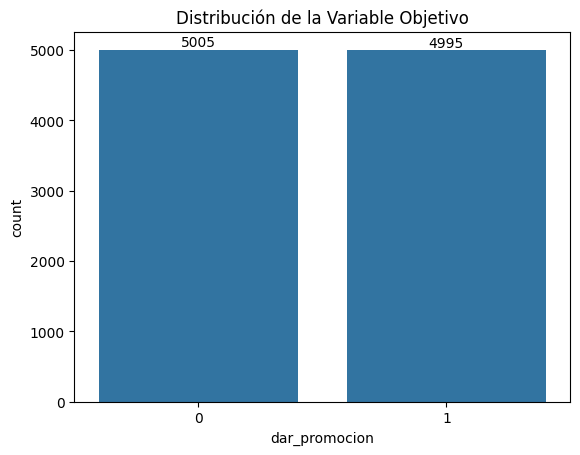

In [42]:
# Distribución de la variable objetivo

ax = sns.countplot(x='dar_promocion', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribución de la Variable Objetivo')
plt.show()

### Correlación entre variables

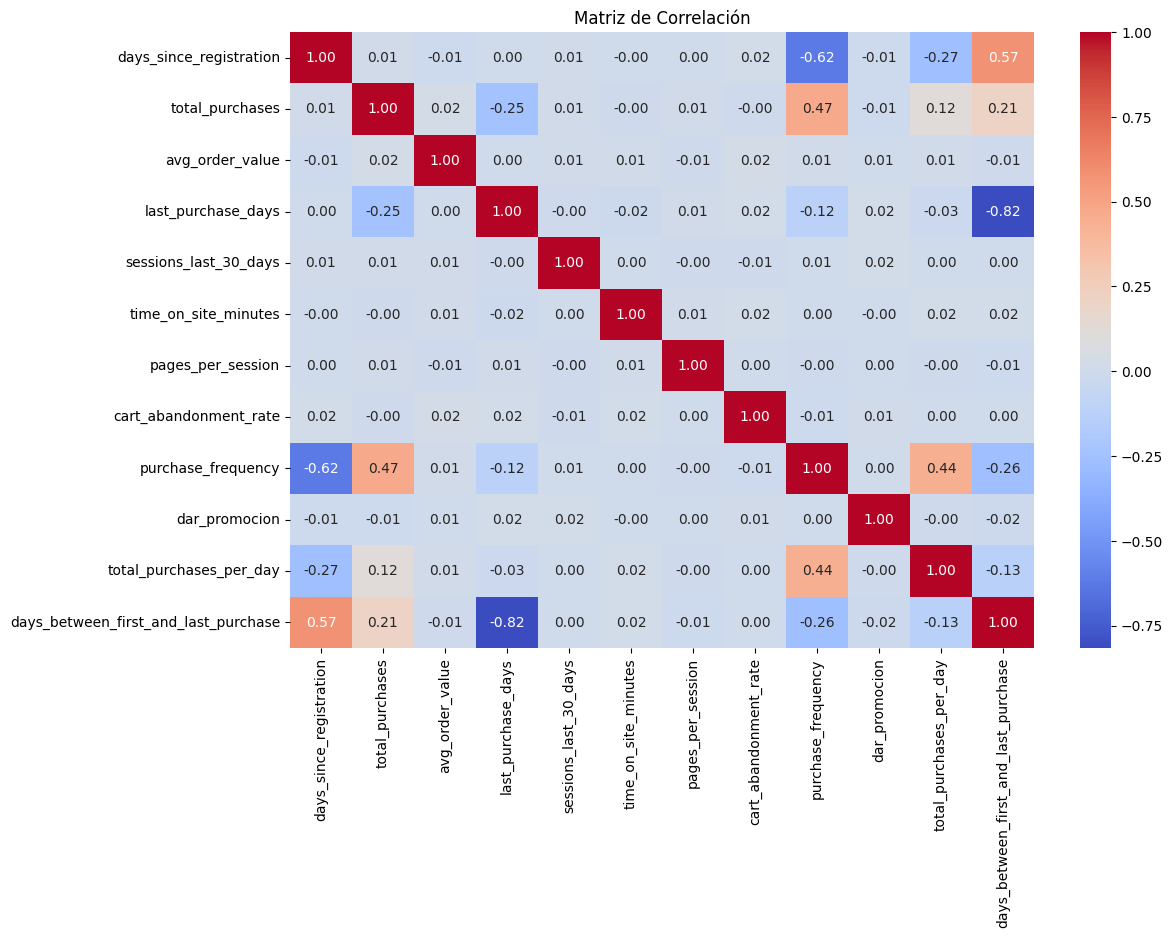

In [43]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

De la correlación entre variables, se puede analizar:

1. Independencia casi total de las variables
    - La mayoría de las variables tienen una correlación extremadamente baja entre sí (cercana a 0).
    - No hay problemas de multicolinealidad. Cada variable aporta información única, pero también significa que el modelo tendrá que esforzarse para encontrar patrones complejos.

2. La variable `dar_promocion` tiene correlación casi nula con las variables numéricas.

3. Correlaciones lógicas
    Hay pequeñas correlaciones como:
    - total_purchases vs purchase_frequency: Tienen una correlación positiva clara. Quien compra más seguido, usualmente tiene un total de compras más alto.
    - total_purchases vs total_purchases_per_day: También correlacionadas, lo cual es redundante.

4. Valores negativos
    - La variable `days_between_first_and_last_purchase` muestra una correlación extraña o nula, probablemente ensuciada por esos valores -998 que se encontraron en el .describe().
    - Por eso, antes de hacer feature engineering, hay que limpiar esos negativos, de lo contrario, cualquier feature nueva basada en esta columna carecerá de sentido.

## 2) Feature engineering (crear más features)

Feature engineering = crear variables nuevas a partir de variables existentes.

- Puede mejorar la señal del modelo (resumir patrones útiles).
- Riesgo: **data leakage** si una feature usa información que no estaría disponible al momento de predecir en producción.

En este caso creamos features derivadas simples (tasas / diferencias) para practicar el flujo.

In [44]:
def aplicar_feature_engineering(df_input):
    df = df_input.copy()
    
    #Limpieza de Coherencia: Se reemplaza el ruido (-998) por NaN para que el imputador haga su trabajo después
    df.loc[df['days_between_first_and_last_purchase'] < 0, 'days_between_first_and_last_purchase'] = np.nan
    
    #Creación de variables
    # 1. 'purchase_velocity': ¿Qué tan rápido compra el usuario desde que se registró?
    df['purchase_velocity'] = df['total_purchases'] / (df['days_since_registration'] + 1)
    
    # 2. 'nav_efficiency': Páginas vistas por minuto, para determinar si navega mucho o va directo al grano
    df['nav_efficiency'] = df['pages_per_session'] / (df['time_on_site_minutes'] + 0.1)
    
    # 3. 'is_active_buyer': Flag para identificar si ha comprado recientemente (basado en el 75% del describe)
    df['is_active_buyer'] = (df['last_purchase_days'] < 30).astype(int)
    
    #Eliminación de columnas que no aportan (IDs)
    if 'user_id' in df.columns:
        df = df.drop(columns=['user_id'])
        
    return df

df_prep = aplicar_feature_engineering(df)
print(f"Dataset listo con {df_prep.shape[1]} columnas.")

Dataset listo con 20 columnas.


## 3) Split de datos (train/test)

Separaremos los datos para simular el escenario real:

- Entrenas con `train`.
- Evalúas con `test` (datos “nuevos” para el modelo).

`random_state` asegura reproducibilidad.

`X` = features (entradas) y `y` = target (lo que quieres predecir).

In [45]:
from sklearn.model_selection import train_test_split

X = df_prep.drop('dar_promocion', axis=1)
y = df_prep['dar_promocion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Registros de entrenamiento: {len(X_train)}")
print(f"Registros de prueba: {len(X_test)}")

Registros de entrenamiento: 7000
Registros de prueba: 3000


## 4) Preprocesamiento: numéricas vs categóricas (y por qué)

En este dataset tienes dos familias de features:

### Variables numéricas
Ejemplos: `avg_order_value`, `time_on_site_minutes`, `purchase_frequency`.

- **Imputación**: muchos modelos no aceptan `NaN`.
- **Escalado** (por ejemplo `StandardScaler`): en modelos lineales (Logistic Regression) ayuda porque hace comparables las magnitudes.

### Variables categóricas
Ejemplos: `age_group`, `location`, `device_type`, `subscription_type`.

- Deben convertirse a números. La opción clásica es **One-Hot Encoding**.
- `handle_unknown='ignore'`: si aparece una categoría nueva en producción, el pipeline no falla.

### Por qué `ColumnTransformer`
Permite aplicar transformaciones diferentes a subconjuntos de columnas (numéricas vs categóricas) en un solo objeto reproducible.

## 5) Pipeline: preprocesamiento + modelo (evitar data leakage)

Usaremos:

- `Pipeline`: encapsula todos los pasos (imputación, escalado, one-hot, modelo).
- `ColumnTransformer`: separa numéricas/categóricas.

Punto clave: si haces imputación/one-hot *antes* del split o fuera del pipeline, podrías mezclar información del test en el entrenamiento (data leakage).

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from category_encoders import BinaryEncoder

# Identificar columnas por tipo
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Transformaciones para números (Imputación por mediana y escalado)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())                     
])

# Transformaciones para categorías (Imputación moda + Binary Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="constant", fill_value="Unknown")),
    ('binary', BinaryEncoder())                    
])

# Unir todo en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Se crea el pipeline completo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Se definen los parámetros a probar
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"Mejor combinación: {grid_search.best_params_}")

Mejor combinación: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


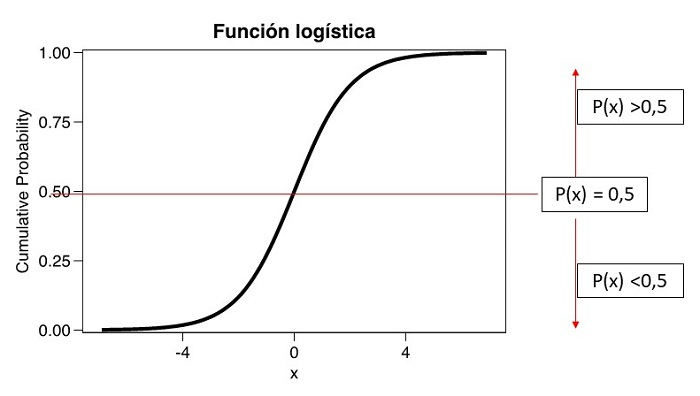

In [48]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Se usa el mejor modelo encontrado por el GridSearch
mejor_modelo = grid_search.best_estimator_

y_pred = mejor_modelo.predict(X_test)
y_proba = mejor_modelo.predict_proba(X_test)[:, 1]

## 6) Métricas de clasificación: cómo leer el reporte

`classification_report` muestra, por clase:

- **precision**: de lo que el modelo predijo como positivo, ¿cuánto fue correcto?
- **recall**: de los positivos reales, ¿cuántos detectó?
- **f1-score**: balance entre precision y recall (útil cuando quieres un trade-off).
- **support**: cuántos ejemplos hay de cada clase.

Promedios:

- **macro avg**: promedio simple entre clases (cada clase pesa igual). Útil si quieres tratar todas las clases con la misma importancia.
- **weighted avg**: promedio ponderado por `support` (la clase más frecuente pesa más). Útil cuando el dataset está desbalanceado.

En binaria, macro vs weighted suelen ser parecidos si no hay mucho desbalance; si hay desbalance fuerte, pueden diferir bastante.

In [49]:
print("--- MÉTRICAS DE RENDIMIENTO ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

--- MÉTRICAS DE RENDIMIENTO ---
ROC-AUC Score: 0.4737

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.49      0.49      0.49      1502
           1       0.48      0.48      0.48      1498

    accuracy                           0.49      3000
   macro avg       0.49      0.49      0.49      3000
weighted avg       0.49      0.49      0.49      3000



### Matriz de confusión (TP/FP/FN/TN)

La matriz de confusión te permite conectar el reporte con conteos concretos:

- **TP (True Positives)**: predijo 1 y era 1.
- **FP (False Positives)**: predijo 1 y era 0.
- **FN (False Negatives)**: predijo 0 y era 1.
- **TN (True Negatives)**: predijo 0 y era 0.

Intuición:

- Subir **precision** suele implicar bajar **recall** (y viceversa).
- En escenarios desbalanceados, `accuracy` puede verse “bien” incluso con un modelo mediocre.

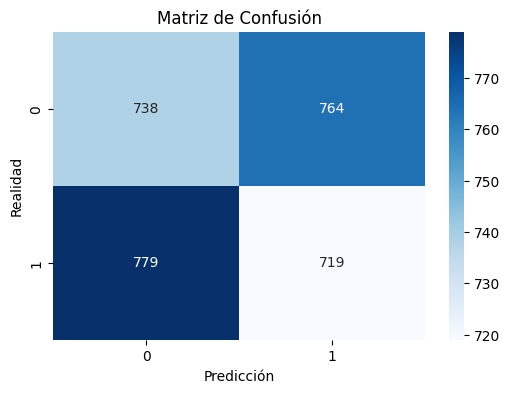

In [50]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

Se realizará una revisión de las variables más relevantes luego del procesamiento. Así se comprobará si alguna de las variables creadas durante el feature engineering aportó significativamente al modelo.

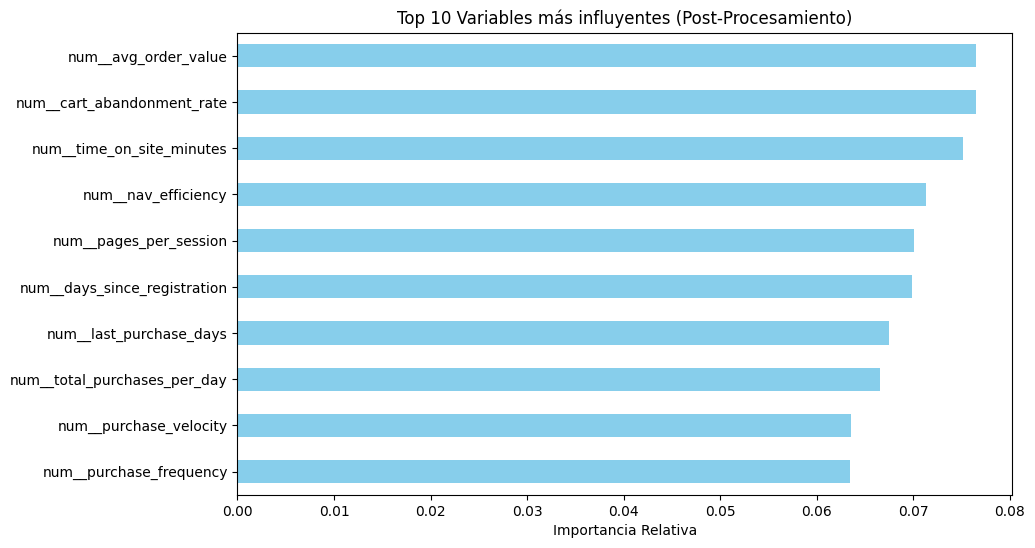

In [51]:
# Extracción de los nombres de las columnas transformadas
nombres_transformados = mejor_modelo.named_steps['preprocessor'].get_feature_names_out()

# Extracción de las importancias del RandomForest
importancias = mejor_modelo.named_steps['classifier'].feature_importances_

# Creación del DataFrame de importancia con los nombres correctos
feat_importances = pd.Series(importancias, index=nombres_transformados)

# Graficar los 10 más influyentes
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 10 Variables más influyentes (Post-Procesamiento)")
plt.xlabel("Importancia Relativa")
plt.show()

Este análisis de importancia indica que el Feature Engineering manual aportó variables con mayor peso relativo que los datos originales. Que `nav_efficiency` supere a variables nativas demuestra que la combinación lógica de métricas (tiempo vs. navegación) captura mejor el comportamiento del usuario, validando la hipótesis de negocio que se planteó.

--- COMPARATIVA DE MODELOS (ROC-AUC) ---
Logistic Regression: 0.5017
Random Forest (Best): 0.4955
Gradient Boosting: 0.4994


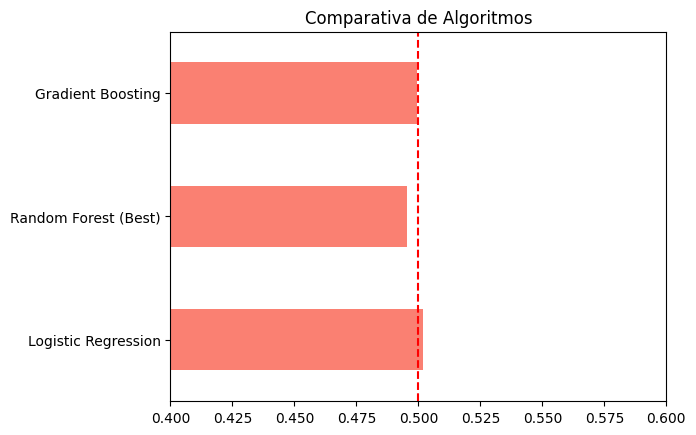

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest (Best)": mejor_modelo.named_steps['classifier'],
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
}

results = {}

print("--- COMPARATIVA DE MODELOS (ROC-AUC) ---")
for nombre, modelo in modelos.items():
    # Se crea un pipeline temporal para cada modelo usando el mismo preprocesador
    temp_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])
    
    # Se usa validación cruzada para mayor robustez
    cv_scores = cross_val_score(temp_pipeline, X, y, cv=5, scoring='roc_auc')
    results[nombre] = cv_scores.mean()
    print(f"{nombre}: {cv_scores.mean():.4f}")

# Visualización rápida
pd.Series(results).plot(kind='barh', color='salmon')
plt.xlim(0.4, 0.6) # Zoom en la zona crítica
plt.axvline(0.5, color='red', linestyle='--') # Línea del azar
plt.title("Comparativa de Algoritmos")
plt.show()

Se observa una similitud de resultados entre modelos lineales (Regresión Logística) y no lineales complejos (Boosting/Forest). Esto confirma que el dataset actual tiene muchísimo ruido. El problema de bajo rendimiento no está relacionado con la arquitectura del algoritmo, sino con la falta de señal predictiva de las variables de entrada.

## 7) Umbral (threshold) y trade-off precision/recall

En clasificación binaria, `predict()` usa un umbral por defecto (típicamente 0.5):

- Si `P(y=1) >= 0.5` entonces predice 1.
- Si no, predice 0.

Cambiar el umbral cambia el equilibrio:

- Umbral **más bajo** (ej. 0.3): más positivos predichos → suele subir `recall` y bajar `precision`.

¿Explicación?
- Voy a aumentar mis positivos pero realmente pocos son buenos. … tendremos más falsos positivos y pocos verdaderos positivos. 
- Aumentan los TP, pero aumentan todavía más los FP (por eso la precisión baja).

---------
- Umbral **más alto** (ej. 0.7): menos positivos predichos → suele subir `precision` y bajar `recall`.

¿Explicación?
- Si subimos el umbral, nos volvemos más estrictos y solo marcamos como positivo a los casos con probabilidad muy alta. Eso reduce los falsos positivos (FP), así que la precision sube, pero aumenta los falsos negativos (FN) (positivos reales que ya no alcanzan el umbral), por lo que el recall baja

Esto es clave en negocio:

- Si el costo de **no dar promoción a alguien que sí la necesitaba** es alto → priorizas `recall`.
- Si el costo de **dar promoción innecesaria** es alto → priorizas `precision`.

In [ ]:
from sklearn.metrics import classification_report

# Se obtienen las probabilidades de la clase positiva (1)
# Se usa el mejor modelo del GridSearch que ya tiene el preprocesador integrado
y_proba_test = mejor_modelo.predict_proba(X_test)[:, 1]

print("--- IMPACTO DEL UMBRAL EN EL NEGOCIO ---")

for thr in [0.3, 0.5, 0.7]:
    # Se aplica el umbral manualmente
    y_pred_thr = (y_proba_test >= thr).astype(int)
    
    print(f"\n" + "="*30)
    print(f"THRESHOLD = {thr}")
    print("="*30)
    
    print(classification_report(y_test, y_pred_thr, target_names=['No Promo', 'Dar Promo']))
    
    # Un pequeño análisis de soporte para entender cuántos estamos afectando con cada umbral
    total_promos = y_pred_thr.sum()
    print(f"Usuarios que recibirían promoción: {total_promos} ({total_promos/len(y_test)*100:.1f}%)")

--- IMPACTO DEL UMBRAL EN EL NEGOCIO ---

THRESHOLD = 0.3
              precision    recall  f1-score   support

    No Promo       0.33      0.00      0.00      1502
   Dar Promo       0.50      1.00      0.66      1498

    accuracy                           0.50      3000
   macro avg       0.42      0.50      0.33      3000
weighted avg       0.42      0.50      0.33      3000

Usuarios que recibirían promoción: 2991 (99.7%)

THRESHOLD = 0.5
              precision    recall  f1-score   support

    No Promo       0.49      0.49      0.49      1502
   Dar Promo       0.48      0.48      0.48      1498

    accuracy                           0.49      3000
   macro avg       0.49      0.49      0.49      3000
weighted avg       0.49      0.49      0.49      3000

Usuarios que recibirían promoción: 1483 (49.4%)

THRESHOLD = 0.7
              precision    recall  f1-score   support

    No Promo       0.50      1.00      0.67      1502
   Dar Promo       0.57      0.01      0.01      

Ajustar el umbral evidencia el costo del error: un Threshold de 0.3 garantiza no perder clientes interesados (Recall 100%), pero a costa de una Precisión del 50%, lo que podría implicar un desperdicio masivo de presupuesto en promociones. La elección del umbral final dependerá del margen operativo: priorizar Recall para crecimiento o Precision para rentabilidad.

## **Actividad**

Prueba:

1. Imputar los numericos con otras estrategias
2. Crea nuevas features
3. Usar BinaryEncoder para las categoricas
4. Usar MinMaxScaler para las numericas
5. Usar RandomForestClassifier para el modelo
6. Usar GridSearchCV para encontrar los mejores hiperparametros
7. Juega con el split de datos


Subir a repositorio invividual con la solución. 